# Ecuación de Crecimiento con Umbral (Threshold Model)


En particular, nos centramos en el **modelo de crecimiento con umbral**, que introduce el concepto de **población mínima viable**.

---

## 1. Deducción del modelo

A diferencia del modelo logístico estándar (donde la población crece hasta una capacidad de carga),  
el modelo con umbral describe escenarios donde:

> Si la población es demasiado baja, no puede sostenerse y tiende a extinguirse.

La ecuación diferencial es:

$$
\frac{dP}{dt} = -r P \left( 1 - \frac{P}{T} \right)
$$

---

### Elementos de la ecuación

- $P(t)$: tamaño de la población  
- $r > 0$: tasa de crecimiento intrínseca  
- $T$: **umbral crítico** (mínimo necesario para sobrevivir)

---

### Interpretación

El término $(1 - P/T)$ actúa como un **interruptor dinámico**:

- Si $P < T$:  
  $$
  (1 - P/T) > 0 \Rightarrow \frac{dP}{dt} < 0
  $$  
  👉 La población **decrece hacia 0**

- Si $P > T$:  
  $$
  (1 - P/T) < 0 \Rightarrow \frac{dP}{dt} > 0
  $$  
  👉 La población **crece sin límite**

---

## 2. Solución analítica

Partimos de:

$$
\frac{dP}{dt} = -r P \left( 1 - \frac{P}{T} \right)
$$

---

### Paso 1: Separación de variables

$$
\int \frac{dP}{P(1 - P/T)} = \int -r \, dt
$$

---

### Paso 2: Fracciones parciales

$$
\frac{1}{P(1 - \frac{P}{T})} = \frac{1}{P} + \frac{1}{T - P}
$$

---

### Paso 3: Integración

$$
\ln|P| - \ln|T - P| = -rt + C
$$

Reordenando:

$$
\ln\left(\frac{T - P}{P}\right) = rt + C
$$

---

### Paso 4: Solución explícita

Aplicando condición inicial $P(0) = P_0$:

$$
P(t) = \frac{T \cdot P_0}{(T - P_0)e^{rt} + P_0}
$$

---

## 3. Interpretación dinámica

Este modelo presenta dos comportamientos radicalmente distintos:

- Si $P_0 < T$ → $P(t) \to 0$  
- Si $P_0 > T$ → $P(t) \to \infty$

---

## 4. Equilibrios

- $P = 0$: **estable (atractor)**  
- $P = T$: **inestable (repulsor)**  

---

## 5. Conceptos clave

### Umbral crítico (repulsor)
El punto $P = T$ actúa como una barrera:

- Cualquier pequeña perturbación aleja al sistema de este punto  
- No es alcanzable en la práctica (inestable)

---

### Atractor (extinción)
El punto $P = 0$ es estable para cualquier condición inicial por debajo del umbral.

---

## 6. Interpretación aplicada

Este modelo es útil para explicar fenómenos como:

- Extinción de especies por baja densidad poblacional  
- Efecto Allee (dificultad de reproducción en poblaciones pequeñas)  
- Colapso de comunidades humanas o fauna tras eventos críticos  

---

## 7. Limitaciones

- No considera saturación (no hay capacidad de carga)  
- Predice crecimiento no acotado  
- No incluye ruido ni migración  

Es un modelo útil para estudiar **puntos especificos**, pero no para dinámica a largo plazo



C:\Users\Deadl\AppData\Local\Temp\ipykernel_43652\124102018.py:22: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  P = odeint(threshold_model, P0, t, args=(r, T))


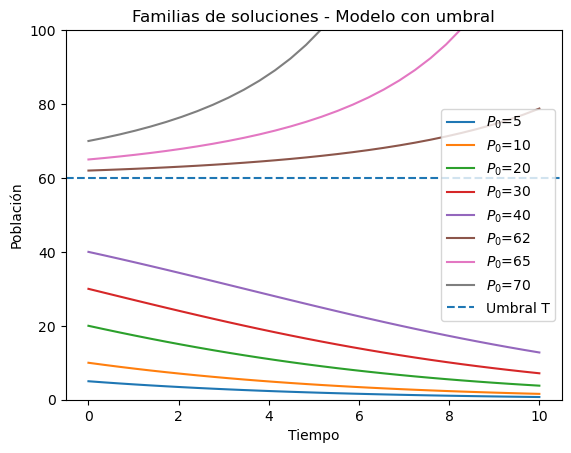

In [62]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import odeint

#Modelo con umbral
def threshold_model(P, t, r, T):
    return -r * P * (1 - P/T)

# Parámetros
r = 0.2
T = 60

# Tiempo
t = np.linspace(0, 10, 30)

# Condiciones iniciales
initial_conditions = [5, 10, 20, 30, 40, 62, 65, 70]

plt.figure()

for P0 in initial_conditions:
    P = odeint(threshold_model, P0, t, args=(r, T))
    plt.plot(t, P, label=f"$P_0$={P0}")

# Línea del umbral
plt.axhline(y=T, linestyle="--", label="Umbral T")

plt.title("Familias de soluciones - Modelo con umbral")
plt.ylim(0, 100)
plt.xlabel("Tiempo")
plt.ylabel("Población")
plt.legend()
plt.savefig("C:/Users/Deadl/OneDrive - Instituto Politecnico Nacional/Documents/Python Scripts/Git/Curiosidades/Images/Crecimiento_umbral.png")
plt.show()

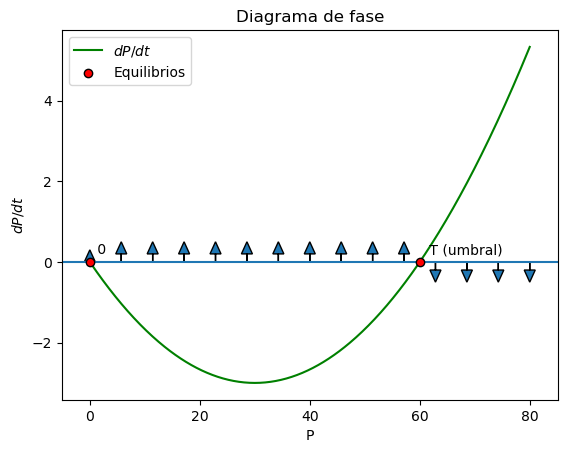

In [ ]:
# Rango de población
P = np.linspace(0, 80, 500)

# Derivada
dPdt = -r * P * (1 - P/T)

plt.figure()
plt.plot(P, dPdt, color = 'green', label="$dP/dt$")

# Línea base
plt.axhline(0)
for n in np.linspace(0, 80, 15):
    slope = r * n * (1 - n / T)
    plt.arrow(n, 0, 0, 0.2*np.sign(slope), 
              head_width=2, head_length=0.3)

# Equilibrios
plt.scatter([0, T], [0, 0], color = 'red', edgecolors='black', zorder=5, label="Equilibrios")
plt.text(0.5, 0.2, " 0")
plt.text(T+1, 0.2, " T (umbral)")

plt.xlabel("P")
plt.ylabel("$dP/dt$")
plt.legend()
plt.title("Diagrama de fase")
plt.savefig("/Images/diagrama_fase_umbral.png")
plt.show()

NameError: name 'A' is not defined